In [1]:
import numpy as np

# Spettri
s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/10k/Y_B_field_10k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3300)
x_axis = range(2500, 3300)
# Labels
posizioni_fit_tot = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

N_spettri, N_punti = s.shape[0], s.shape[1]

Provo ad addestrare un LSTM a prevedere le posizioni dei picchi a partire dagli spettri


### Importazioni

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import GaussianNoise

### 1. CARICAMENTO E PREPARAZIONE DEI DATI

In [3]:
# Supponiamo che 's' sia il tuo array di 10k spettri (es. shape: (10000, N_punti))
# e 'posizioni_fit_tot' sia il tuo array di labels (shape: (10000, 8))
# Sostituisci queste due righe con il caricamento effettivo dei tuoi dati se sono su file
# X_raw = np.load('spettri.npy') 
# y_raw = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

X_raw = s[np.argsort(B)]  # Shape attesa: (10000, N_punti) ordinati in base a B
B = np.sort(B)  # Ordino anche B
y = np.sort(posizioni_fit_tot, axis=1)  # Shape attesa: (10000, 8) sono già ordinati in base a B

# Normalizzazione degli input (Spettri) e degli output (Posizioni)
# Usiamo MinMaxScaler per portare tutto nel range [0, 1], ideale per le reti neurali
scaler_X = MinMaxScaler()

# Per scalare X, dobbiamo prima "appiattirlo", scalarlo e poi rimetterlo a posto
X_scaled = scaler_X.fit_transform(X_raw.T).T 
y_scaled = (y - 2500) / 800 # Le labels così sono da 0 (2.5 GHz) a 1 (3.3 GHz) 

# Reshape di X per la LSTM: (campioni, timestep, features)
# features = 1 perché ad ogni "passo" (frequenza) hai un solo valore (l'intensità)
N_campioni, N_punti = X_scaled.shape
X_lstm = X_scaled.reshape((N_campioni, N_punti, 1))

# HACK: separo in train/test tenendo traccia degli indici
indici_originali = np.arange(len(X_lstm))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_lstm, 
    y_scaled, 
    indici_originali, # <-- Aggiunto qui
    test_size=0.20, 
    random_state=42
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (8000, 800, 1)
Shape y_train: (8000, 8)
Shape X_test: (2000, 800, 1)


### 2. COSTRUZIONE DELL'ARCHITETTURA LSTM


lstm semplice

In [ ]:
modello = Sequential()

# Input layer
modello.add(Input(shape=(N_punti, 1)))

# SUCCESSIVAMENTE: AGGIUNGERE RUMORE BIANCO (GAUSSIANO)
# Regola lo stddev in base all'ampiezza tipica del rumore nei tuoi spettri normalizzati.
modello.add(GaussianNoise(stddev=0.01))

# Primo layer LSTM con Regolarizzazione L2 sui pesi
modello.add(LSTM(64, activation='tanh', return_sequences=True, 
                 kernel_regularizer=l2(0.001), recurrent_dropout=0.2))

# Dropout al 20% dopo il primo strato
modello.add(Dropout(0.2))

# Secondo layer LSTM
modello.add(LSTM(32, activation='tanh', return_sequences=False,
                 kernel_regularizer=l2(0.001), recurrent_dropout=0.2))

# Dropout al 20% prima dell'output
modello.add(Dropout(0.2))

# Layer di Output
modello.add(Dense(8))

modello.compile(optimizer='adam', loss='mse', metrics=['mae'])
modello.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 800, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,576 (115.53 KB)

 Trainable params: 29,576 (115.53 KB)

 Non-trainable params: 0 (0.00 B)

### 3. ADDESTRAMENTO

> 1 ora!

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Se per 5 epoche non migliora, dimezza il learning rate (factor=0.5)
riduci_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# EarlyStopping ferma l'addestramento se il modello smette di migliorare sul validation set,
# evitando l'overfitting e facendoti risparmiare tempo.
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Fit del modello
history = modello.fit(
    X_train, 
    y_train,
    epochs=60,             # Numero massimo di iterazioni (verrà fermato prima dall'EarlyStopping se converge)
    batch_size=128,          # Quanti spettri processare insieme (aumentalo a 128 o 256 per maggiore velocità)
    validation_data=(X_test, y_test),
    callbacks=[early_stop, riduci_lr],
    
    verbose=1
)

Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 952ms/step - loss: 0.1112 - mae: 0.1631 - val_loss: 0.0469 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 943ms/step - loss: 0.0452 - mae: 0.0915 - val_loss: 0.0251 - val_mae: 0.0416 - learning_rate: 0.0010
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 0.0273 - mae: 0.0807 - val_loss: 0.0153 - val_mae: 0.0396 - learning_rate: 0.0010
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - loss: 0.0187 - mae: 0.0737 - val_loss: 0.0105 - val_mae: 0.0384 - learning_rate: 0.0010
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 0.0141 - mae: 0.0688 - val_loss: 0.0081 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0112 - mae: 0.0643 - val_loss: 0.0065 - val_mae: 0.0389 - learning_rate: 0.0010
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - loss: 0.0095 - mae: 0.0622 - val_loss: 0.0054 - val_mae: 0.0381 - learning_rate: 0.0010
Epoch 8/60
63/

In [13]:
modello.save('modello_peak_position_lstm_1layer.keras')

### 4. INFERENZA E RICONVERSIONE

In [6]:
# Testiamo il modello facendo una predizione sul set di test
predizioni_scaled = modello.predict(X_test)

# Le predizioni sono tra 0 e 1, dobbiamo riportarle alle frequenze reali (es. 2870)
predizioni = predizioni_scaled * 800 + 2500

y_test_reali = y_test * 800 + 2500

# Stampiamo il primo spettro di test per confronto
print("\nConfronto sul primo spettro di test (Valori reali vs Predetti):")
print(f"Reali:   {np.round(y_test_reali[0], 2)}")
print(f"Predetti:{np.round(predizioni[0], 2)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step

Confronto sul primo spettro di test (Valori reali vs Predetti):
Reali:   [2732.09 2795.32 2820.37 2848.98 2861.54 2935.62 2956.78 3007.79]
Predetti:[2757.6  2796.15 2823.91 2847.97 2892.13 2925.65 2947.98 2979.09]


In [7]:
idx_test[0]

6252

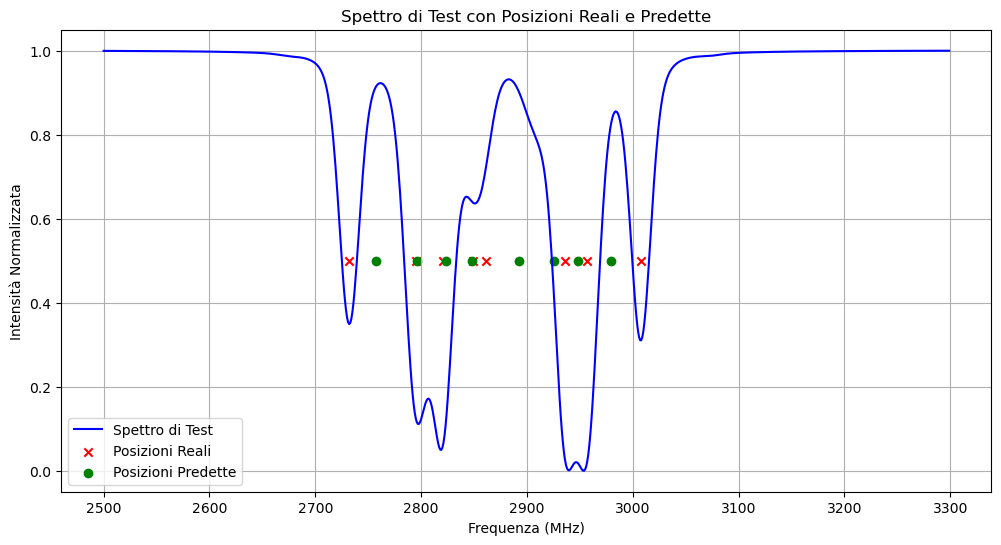

In [11]:
# plotto il primo spettro di test con le posizioni reali e predette
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(x_axis, X_test[0], label='Spettro di Test', color='blue') # X_raw[idx_test[0]]
plt.scatter(y_test_reali[0], [0.5]*8, label='Posizioni Reali', color='red', marker='x')
plt.scatter(predizioni[0], [0.5]*8, label='Posizioni Predette', color='green', marker='o')
plt.title('Spettro di Test con Posizioni Reali e Predette')
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità Normalizzata')
plt.legend()
plt.grid()
plt.show()

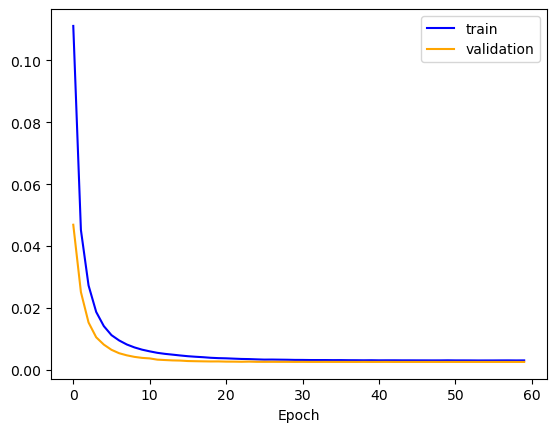

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [9]:
# plot loss
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='validation')
plt.xlabel('Epoch')
plt.legend()
plt.show()
plt.clf()

# save plot to file
plt.show()
plt.clf()